
# Player Performance → Salary (NBA): EDA, Correlation Pruning, Lasso Feature Selection & Linear Regression

We predict **Salary** from NBA player attributes (per-game and advanced statistics + a few categorical variables).

**Pipeline**
1. **Brief EDA**: summary stats, missingness, histograms, category counts, and a **correlation matrix**.
2. **Correlation pruning**: remove highly correlated numeric predictors to reduce multicollinearity.
3. **Train/Test split**.
4. **Lasso regression (with cross‑validation)** on the training set to select useful features.
5. **Linear regression** fit on the selected features.
6. **Evaluation & visualization** (predicted vs. true on the test set; error metrics).

**Dataset (NBA 2022–23)**
We load a public CSV combining player salaries and statistics for the 2022–23 NBA season. Two mirrors are provided below; the first contains both per‑game and advanced metrics with salary; the second is a similar mirror for the same season.

* Primary: `nba_2022-23_all_stats_with_salary.csv` (GitHub mirror)
* Secondary (fallback): `nba_salaries.csv` (GitHub mirror)

> Note: If the first URL is temporarily unavailable, the code automatically falls back to the second.


In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.feature_selection import SelectFromModel
from sklearn import metrics

import plotly.express as px

pd.set_option('display.max_columns', 200)
RANDOM_STATE = 42

In [99]:
PRIMARY_URL = "https://raw.githubusercontent.com/Wh1teeee/nba-dataset/main/nba_2022-23_all_stats_with_salary.csv"
FALLBACK_URL = "https://raw.githubusercontent.com/Valve04/Dataset/main/nba_salaries.csv"

# this will try to get the data from the first link, and fallback to the
# second link in case the first one fails
try:
    raw = pd.read_csv(PRIMARY_URL)
    source_used = 'primary'
except Exception:
    raw = pd.read_csv(FALLBACK_URL)
    source_used = 'fallback'

raw.head()


,Unnamed: 0,Player Name,Salary,Position,Age,Team,GP,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Total Minutes,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,0,Stephen Curry,48070014,PG,34,GSW,56,56,34.7,10.0,20.2,0.493,4.9,11.4,0.427,5.1,8.8,0.579,0.614,4.6,5.0,0.915,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,1941,24.1,0.656,0.564,0.248,2.3,16.8,9.7,30.0,1.3,0.9,12.5,31.0,5.8,2.0,7.8,0.192,7.5,0.1,7.5,4.7
1,1,John Wall,47345760,PG,32,LAC,34,3,22.2,4.1,9.9,0.408,1.0,3.2,0.303,3.1,6.7,0.459,0.457,2.3,3.3,0.681,0.4,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,755,13.6,0.498,0.322,0.334,2.1,11.4,6.8,35.3,1.8,1.4,17.1,27.0,-0.4,0.7,0.3,0.020,-0.8,-0.4,-1.2,0.1
2,2,Russell Westbrook,47080179,PG,34,LAL/LAC,73,24,29.1,5.9,13.6,0.436,1.2,3.9,0.311,4.7,9.7,0.487,0.481,2.8,4.3,0.656,1.2,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,2126,16.1,0.513,0.289,0.317,4.7,16.5,10.8,38.6,1.7,1.3,18.4,27.7,-0.6,2.6,1.9,0.044,0.3,-0.1,0.2,1.2
3,3,LeBron James,44474988,PF,38,LAL,55,54,35.5,11.1,22.2,0.500,2.2,6.9,0.321,8.9,15.3,0.580,0.549,4.6,5.9,0.768,1.2,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,1954,23.9,0.583,0.309,0.268,3.7,20.8,12.5,33.5,1.2,1.4,11.6,33.3,3.2,2.4,5.6,0.138,5.5,0.6,6.1,4.0
4,4,Kevin Durant,44119845,PF,34,BRK/PHO,47,47,35.6,10.3,18.3,0.560,2.0,4.9,0.404,8.3,13.4,0.617,0.614,6.5,7.1,0.919,0.4,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,1672,25.9,0.677,0.267,0.387,1.2,19.5,10.5,24.5,1.0,3.4,13.4,30.7,4.7,2.1,6.8,0.194,6.0,1.2,7.1,3.9


# 1 Preprocessing

In [100]:
raw = raw.drop(columns= "Unnamed: 0")
print(raw.info())
#raw.columns = [c.strip() for c in raw.columns]
#display(raw.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 467 entries, 0 to 466
Data columns (total 51 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Player Name    467 non-null    object 
 1   Salary         467 non-null    int64  
 2   Position       467 non-null    object 
 3   Age            467 non-null    int64  
 4   Team           467 non-null    object 
 5   GP             467 non-null    int64  
 6   GS             467 non-null    int64  
 7   MP             467 non-null    float64
 8   FG             467 non-null    float64
 9   FGA            467 non-null    float64
 10  FG%            466 non-null    float64
 11  3P             467 non-null    float64
 12  3PA            467 non-null    float64
 13  3P%            454 non-null    float64
 14  2P             467 non-null    float64
 15  2PA            467 non-null    float64
 16  2P%            463 non-null    float64
 17  eFG%           466 non-null    float64
 18  FT        

In [101]:
nan_counts = raw.isna().sum().sort_values(ascending=False)
nan_pct = (nan_counts / len(raw) * 100).round(2)
nan_df = pd.DataFrame({"NaN_count": nan_counts, "NaN_%": nan_pct})
# Filter to show only features with NaNs
display(nan_df[nan_df['NaN_count'] > 0])

,NaN_count,NaN_%
FT%,23,4.93
3P%,13,2.78
2P%,4,0.86
eFG%,1,0.21
FTr,1,0.21
TS%,1,0.21
FG%,1,0.21
3PAr,1,0.21


We have some NAs. We will calculate the average value for each feature, and fill the NAs with that value. But first we separate the numeric from the categorical features

In [102]:
TARGET = "Salary"

numeric_cols = raw.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove(TARGET)

categorical_cols = raw.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}):", numeric_cols[:10], '...' if len(numeric_cols)>10 else '')
print(f"Categorical columns ({len(categorical_cols)}):", categorical_cols[:10], '...' if len(categorical_cols)>10 else '')

Numeric columns (47): ['Age', 'GP', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%'] ...
Categorical columns (3): ['Player Name', 'Position', 'Team'] 


In [103]:
df = raw.copy()
for col in numeric_cols:
    if df[col].isnull().any():
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)
        print(f"Filled missing values in '{col}' with its mean: {mean_val:.2f}")

print(raw.isnull().sum()[df.isnull().sum() > 0])

Filled missing values in 'FG%' with its mean: 0.47
Filled missing values in '3P%' with its mean: 0.33
Filled missing values in '2P%' with its mean: 0.53
Filled missing values in 'eFG%' with its mean: 0.53
Filled missing values in 'FT%' with its mean: 0.75
Filled missing values in 'TS%' with its mean: 0.56
Filled missing values in '3PAr' with its mean: 0.40
Filled missing values in 'FTr' with its mean: 0.25
Series([], dtype: int64)


Lets plot some distributions of the numerical features.

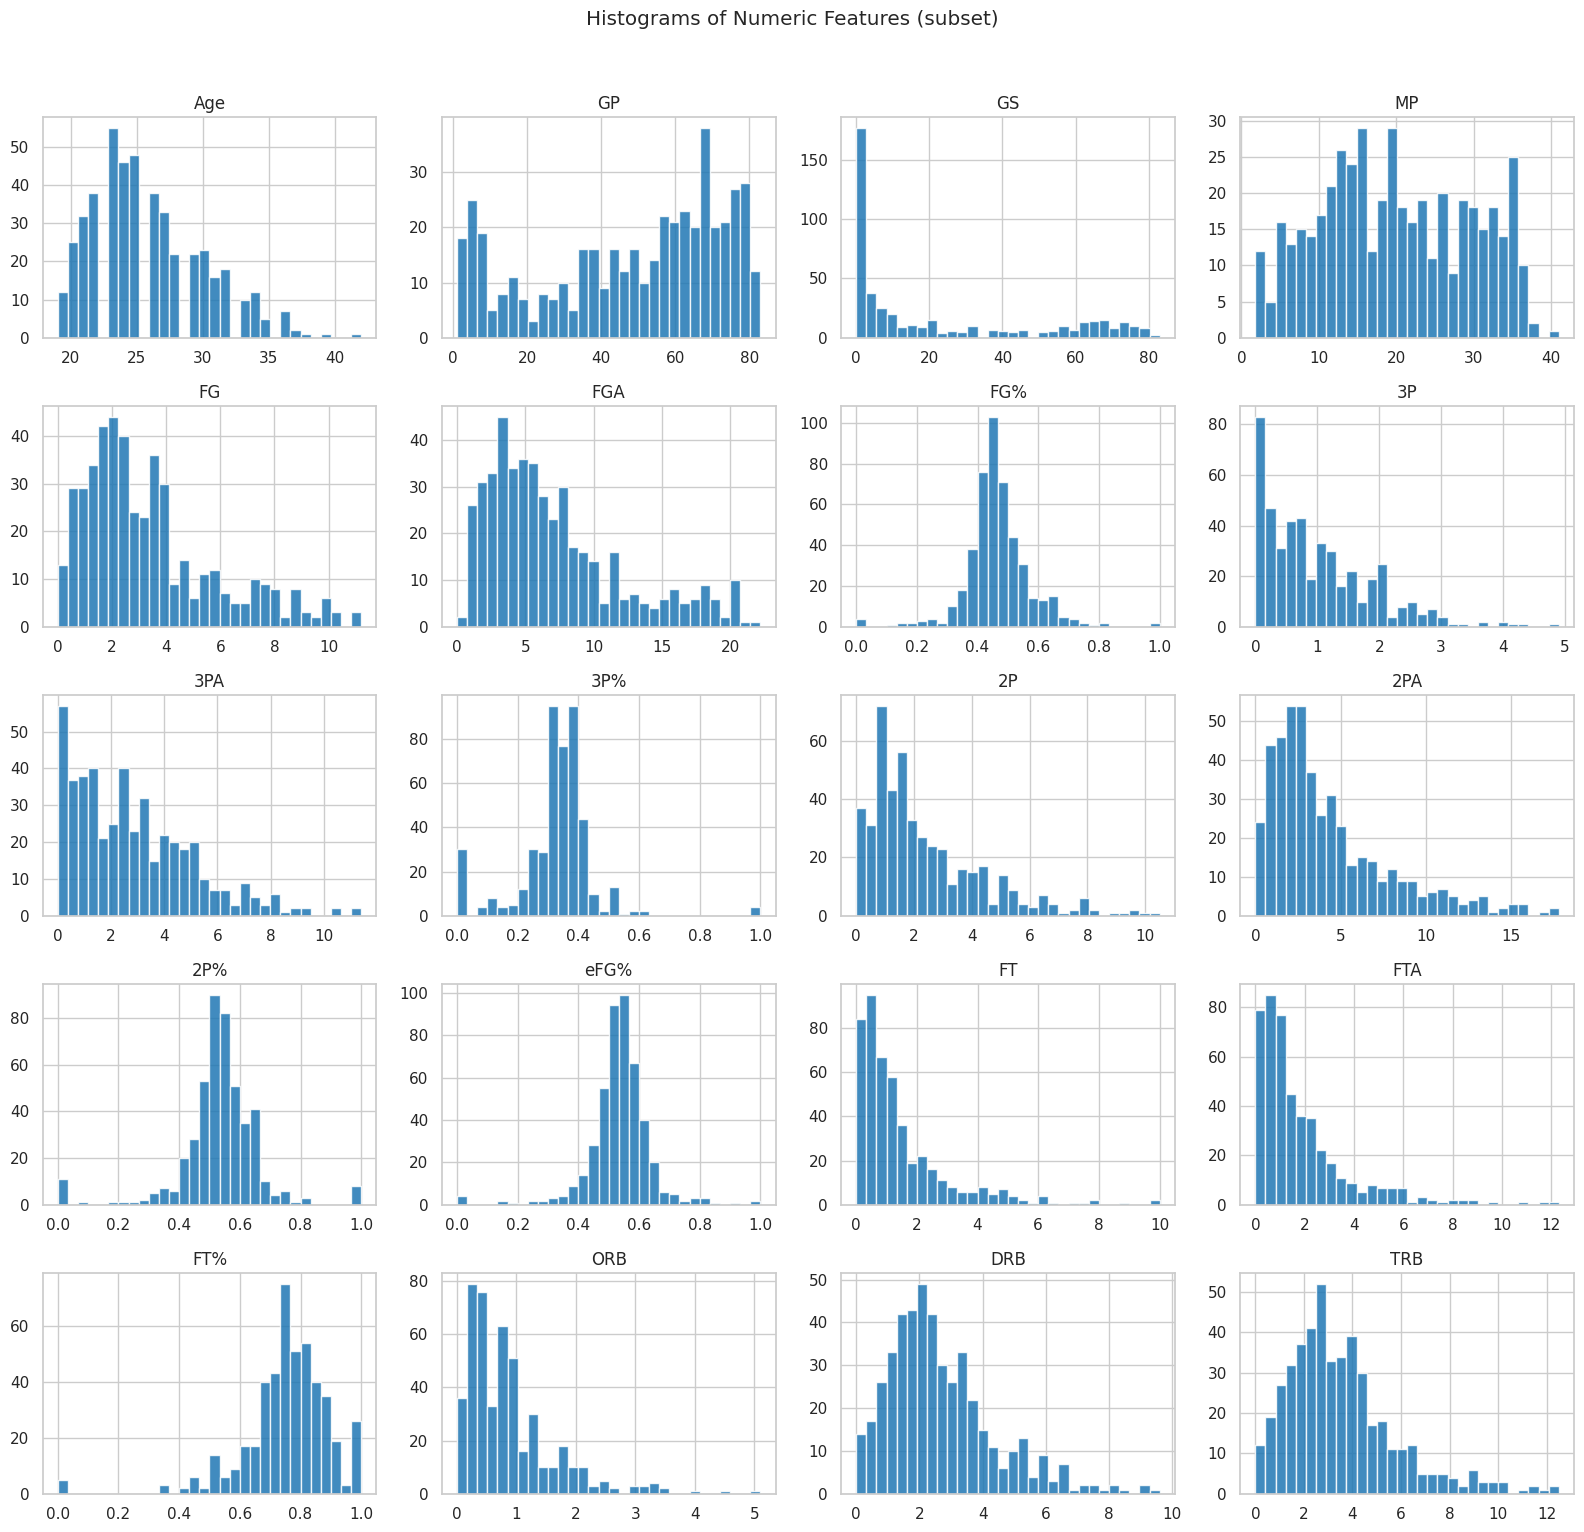

In [104]:
num_to_plot = numeric_cols[:20]

n_cols = 4
n_rows = int(np.ceil(len(num_to_plot)/n_cols)) # this is only to get a plot with 5 rows
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()
for i, col in enumerate(num_to_plot):
    ax = axes[i]

    ax.hist(df[col].dropna(), bins=30, color="#1f77b4", alpha=0.85)
    ax.set_title(col)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
fig.suptitle('Histograms of Numeric Features (subset)', y=1.02)
plt.tight_layout()
plt.show()

We will select only one categorical variable. We could potentially combine the rare categories with the frequent ones. These rare categories seem to be players that play in two positions.

In [105]:
print("Categorical columns", categorical_cols)

Categorical columns ['Player Name', 'Position', 'Team']


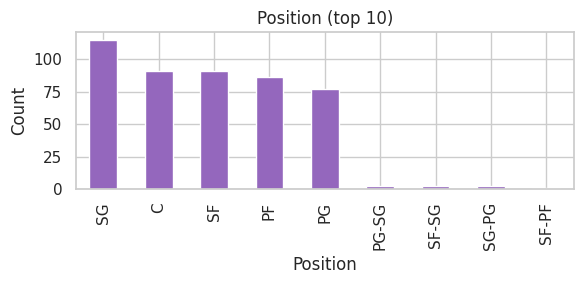

In [106]:
vc = df['Position'].value_counts().head(10)
ax = vc.plot(kind='bar', figsize=(6,3), color='#9467bd')
ax.set_title('Position (top 10)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

We build a correlation matrix to see potential correlation across features. There are many fetures that are transformations of other features, so they are correlated.

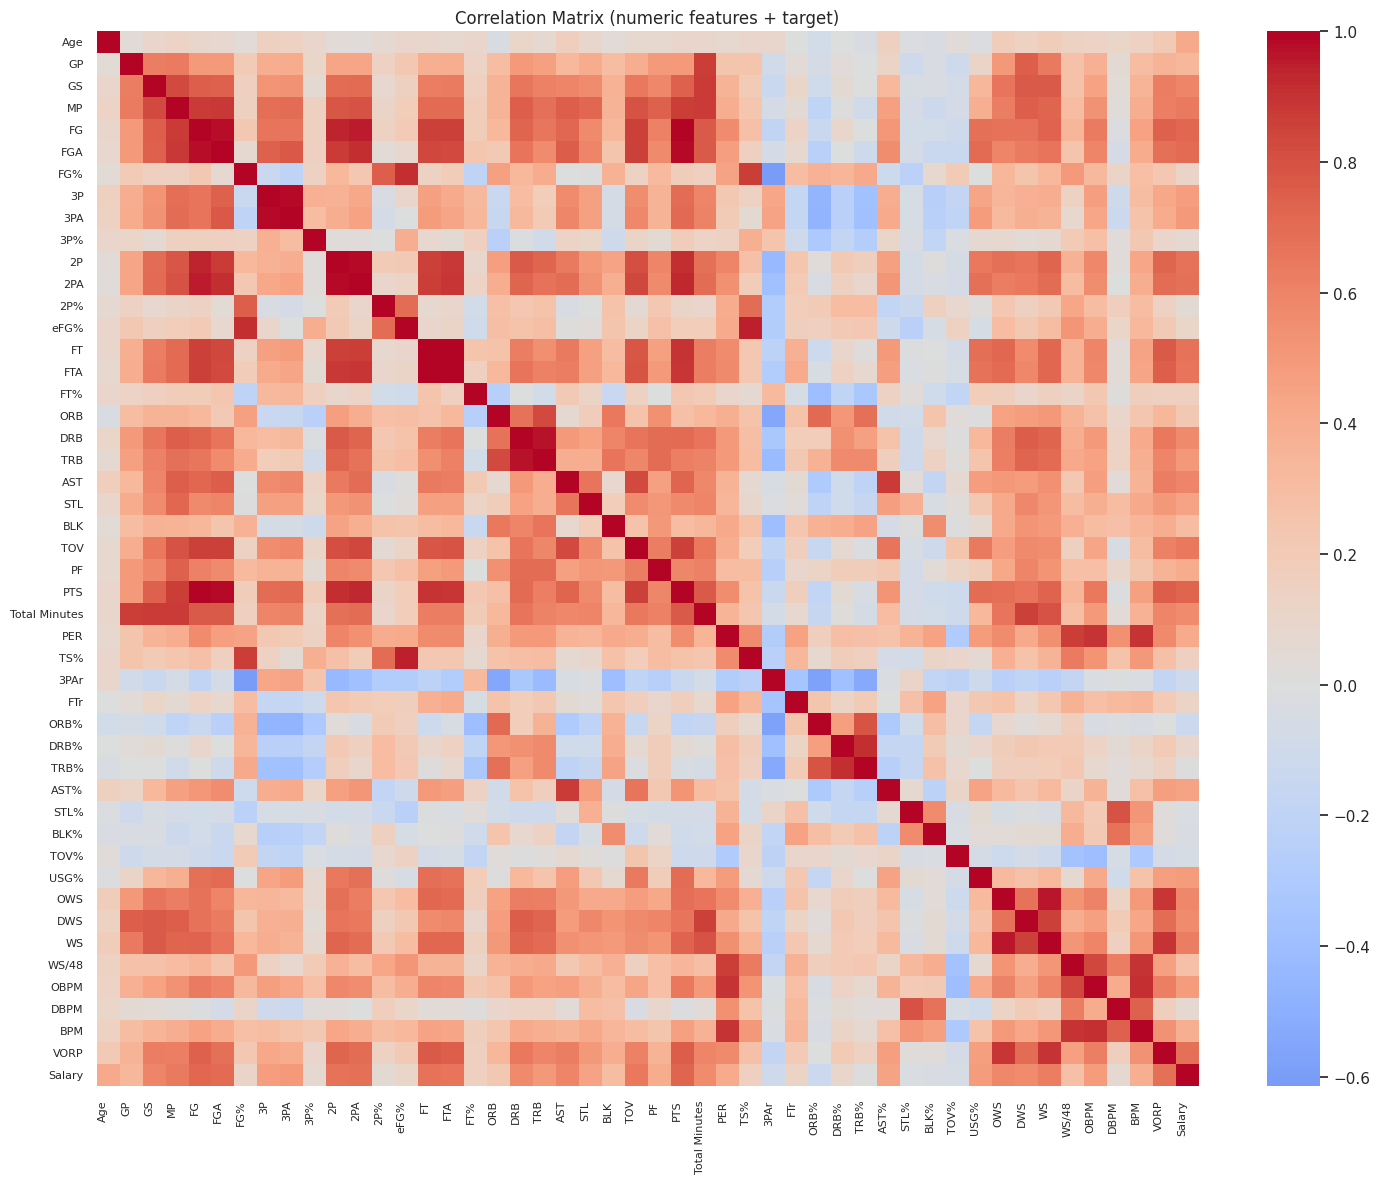

In [107]:
corr = df[numeric_cols + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(15,12)) # Increased figure size for better spacing
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, fmt='.2f', square=False, ax=ax)
ax.set_title('Correlation Matrix (numeric features + target)')

# Reduce font size of x and y axis tick labels
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

# Explicitly set rotation and alignment for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right') # Rotate x-labels and align right
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')  # Align y-labels right

plt.tight_layout()
plt.show()

Some features are correlated. Let's remove the ones that have a correlation higher than 80%

In [108]:
CORR_THRESHOLD = 0.80
corr_pred = df[numeric_cols].corr().abs()
upper = corr_pred.where(np.triu(np.ones(corr_pred.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
print(f"Correlation threshold: {CORR_THRESHOLD}")
print(f"Highly correlated numeric predictors to drop ({len(to_drop_corr)}):", to_drop_corr)

X = df.drop(columns=[TARGET] + to_drop_corr)
y = df[TARGET]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()
print(f"Numeric features retained ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features retained ({len(categorical_features)}): {categorical_features}")

Correlation threshold: 0.8
Highly correlated numeric predictors to drop (23): ['MP', 'FG', 'FGA', '3PA', '2P', '2PA', 'eFG%', 'FT', 'FTA', 'TRB', 'TOV', 'PTS', 'Total Minutes', 'TS%', 'TRB%', 'AST%', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP']
Numeric features retained (24): ['Age', 'GP', 'GS', 'FG%', '3P', '3P%', '2P%', 'FT%', 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'PF', 'PER', '3PAr', 'FTr', 'ORB%', 'DRB%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS']
Categorical features retained (3): ['Player Name', 'Position', 'Team']


We have to divide the set into train and test sets. We don't touch the test set for anything until we have our model trained with the final set of features.

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
X_train.shape, X_test.shape


((373, 27), (94, 27))

27 predictors are a lot for 373 observations for training. We will reduce the number of predictors using LassoCV. But first we normalize the features.

In [127]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

Now we will one-hot-encode "Position" and drop the rest of the categorical features

In [128]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop="first")

X_train_encoded = X_train_scaled.copy()
X_test_encoded = X_test_scaled.copy()

# Fit and transform 'Position' from the training set
encoder.fit(X_train_encoded[['Position']])
X_train_cat_encoded = encoder.transform(X_train_encoded[['Position']])
X_test_cat_encoded = encoder.transform(X_test_encoded[['Position']])

X_train_cat_df = pd.DataFrame(
    X_train_cat_encoded,
    columns=encoder.get_feature_names_out(["Position"]),
    index=X_train_encoded.index
)
X_test_cat_df = pd.DataFrame(
    X_test_cat_encoded,
    columns=encoder.get_feature_names_out(["Position"]),
    index=X_test_encoded.index
)

# Drop all original categorical features ('Player Name', 'Team', and 'Position')
categorical_features_to_drop = [col for col in ['Player Name', 'Position', 'Team'] if col in X_train_encoded.columns]
X_train_encoded = X_train_encoded.drop(columns=categorical_features_to_drop)
X_test_encoded = X_test_encoded.drop(columns=categorical_features_to_drop)

# Concatenate the one-hot encoded 'Position' features
X_train_encoded = pd.concat([X_train_encoded, X_train_cat_df], axis=1)
X_test_encoded = pd.concat([X_test_encoded, X_test_cat_df], axis=1)

# 2 Analysis of feature importance

LassoCV will calculate the regression coefficients of each feature k times. It applies a penalty to them, and if they end up being shruk close to zero, they are dropped.

In [112]:
lasso_selector = LassoCV(cv=10, random_state=42, max_iter=10000)
lasso_selector.fit(X_train_encoded.values, y_train)

selector = SelectFromModel(estimator=lasso_selector, prefit=True)

# Transform the encoded data using the selector into NumPy arrays
X_train_selected_np = selector.transform(X_train_encoded.values)
X_test_selected_np = selector.transform(X_test_encoded.values)

all_feature_names = X_train_encoded.columns.to_list()
selected_mask = selector.get_support() # get selected features

# Get the names of features selected by Lasso
# they were removed when transforming the data into arrays
selected_features_names_after_lasso = [name for name, keep in zip(all_feature_names, selected_mask) if keep]

# Convert NumPy arrays back to DataFrames with proper column names
X_train_selected = pd.DataFrame(X_train_selected_np, columns=selected_features_names_after_lasso, index=X_train_encoded.index)
X_test_selected = pd.DataFrame(X_test_selected_np, columns=selected_features_names_after_lasso, index=X_test_encoded.index)

# Update the global selected_features variable to be this list of names
selected_features = selected_features_names_after_lasso

print(f"Shape of X_train_selected: {X_train_selected.shape}")
print(f"Shape of X_test_selected: {X_test_selected.shape}")
print(f"Selected features ({len(selected_features)}): {selected_features}")

Shape of X_train_selected: (373, 16)
Shape of X_test_selected: (94, 16)
Selected features (16): ['Age', 'GS', '3P', '3P%', '2P%', 'ORB', 'DRB', 'AST', 'BLK', 'ORB%', 'DRB%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'Position_SF']


3P%, ORB% BLK% and DRB% are likely function of 3P, ORB, BLK and DRB that escaped our previous filters. We remove them manually.

In [113]:
features_to_drop_manually = ['3P', 'ORB', 'DRB', 'BLK'] # Features to remove by name

# Drop the columns by name from the DataFrames
X_train_selected = X_train_selected.drop(columns=features_to_drop_manually)
X_test_selected = X_test_selected.drop(columns=features_to_drop_manually)

# Update the list of selected features by filtering out the ones manually dropped
selected_features = [f for f in selected_features if f not in features_to_drop_manually]

print(f"Selected features removed. New shape of X_train_selected: {X_train_selected.shape}")
print(f"New selected features ({len(selected_features)}): {selected_features}")

Selected features removed. New shape of X_train_selected: (373, 12)
New selected features (12): ['Age', 'GS', '3P%', '2P%', 'AST', 'ORB%', 'DRB%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'Position_SF']


# 3 Train the model and check coefficients

We finally train the linear regression

In [114]:
final_model = LinearRegression()
final_model.fit(X_train_selected, y_train)

LinearRegression()

Let's look at our coefficients

In [115]:
print(f"Intercept: {final_model.intercept_:.2f}")
coefs = pd.Series(final_model.coef_, index=selected_features)

Intercept: 7896931.43


Text(0.5, 1.0, 'Linear regression model, small regularization')

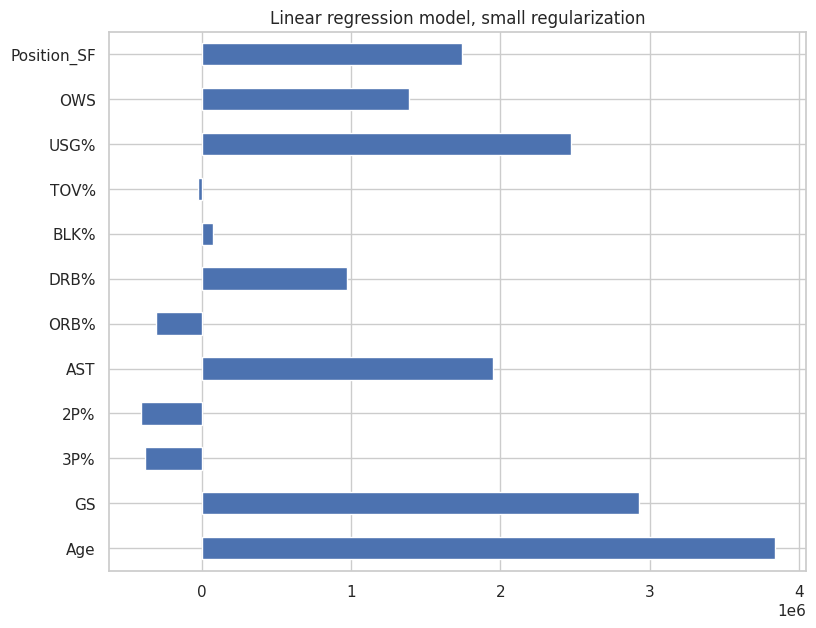

In [116]:
coefs.plot(kind='barh', figsize=(9, 7))
plt.title('Linear regression model, regularization')

*ORB: offensive rebound* has a negative coefficient. If you are into sports, this will be counter intuitive that the players with a higher offensive rebound tend to have lower salaries, all else being equal.

# 4 Analyse predictions in test data

That's it. Our model has been created, and unless we want to remove low importance features manually, we can proceed.
Now we must see how it performs in our test data

In [117]:
y_pred = final_model.predict(X_test_selected)

n = len(y_test) # Number of observations
p = X_test_selected.shape[1] # Number of predictors

r2 = metrics.r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Test R^2: {r2:.3f}, Test adjust R2:{ adjusted_r2:.3f} , Test MAE: {mae:,.0f},  Test RMSE: {rmse:,.0f}")

Test R^2: 0.751, Test adjust R2:0.714 , Test MAE: 4,545,555,  Test RMSE: 5,750,820


# Optional statistics section

In [118]:
# Calculate F-statistic and p-value for R-squared significance
# F-statistic formula: F = (R^2 / p) / ((1 - R^2) / (n - p - 1))
# Need to import scipy.stats.f
from scipy.stats import f

f_statistic = (r2 / p) / ((1 - r2) / (n - p - 1))
p_value_f = f.sf(f_statistic, p, n - p - 1)

print(f"F-statistic: {f_statistic:.2f}, P-value for R^2 significance: {p_value_f:.8f}")

F-statistic: 20.35, P-value for R^2 significance: 0.00000000


F statistic: checks if your model, as a whole, has any predictive power or if the relationship observed between your predictors and the target variable could have occurred by random chance. A larger F-statistic generally indicates a more significant model.  p-value: the probability of observing an F-statistic as extreme as, or more extreme than, the one calculated, assuming the null hypothesis (that all coefficients are zero) is true.

# Visualizing predictions

The accuracies don't look too bad, but improvable. Lets plot the predictions vs labels to see what happened.

In [119]:
# Plotly express (px) is like matplotlib, but allows some interactive plots
# You can achieve the same with a simple scatter plot in matplotlib.
y_pred_series = pd.Series(y_pred, index=y_test.index)
plot_df = pd.DataFrame({'True Salary': y_test, 'Predicted Salary': y_pred_series})
plot_df['Original Index'] = y_test.index

fig = px.scatter(
    plot_df,
    x='True Salary', y='Predicted Salary',
    title='True vs. Predicted Salary (Test Set, NBA 2022–23)',
    hover_data=['Original Index', 'True Salary', 'Predicted Salary'],
    labels={'True Salary': 'True Salary (USD)', 'Predicted Salary': 'Predicted Salary (USD)'}
)
fig.update_traces(marker=dict(size=8, opacity=0.7), selector=dict(mode='markers'))
fig.update_layout(hovermode='closest')
fig.add_shape(
    type='line', line=dict(dash='dash', color='red'),
    x0=plot_df['True Salary'].min(), y0=plot_df['True Salary'].min(),
    x1=plot_df['True Salary'].max(), y1=plot_df['True Salary'].max()
)
fig.show()

# 5 Residuals' distribution

We must check now if out hypothesis of normal and uncorrelated residuals and homoskedasticity are true.

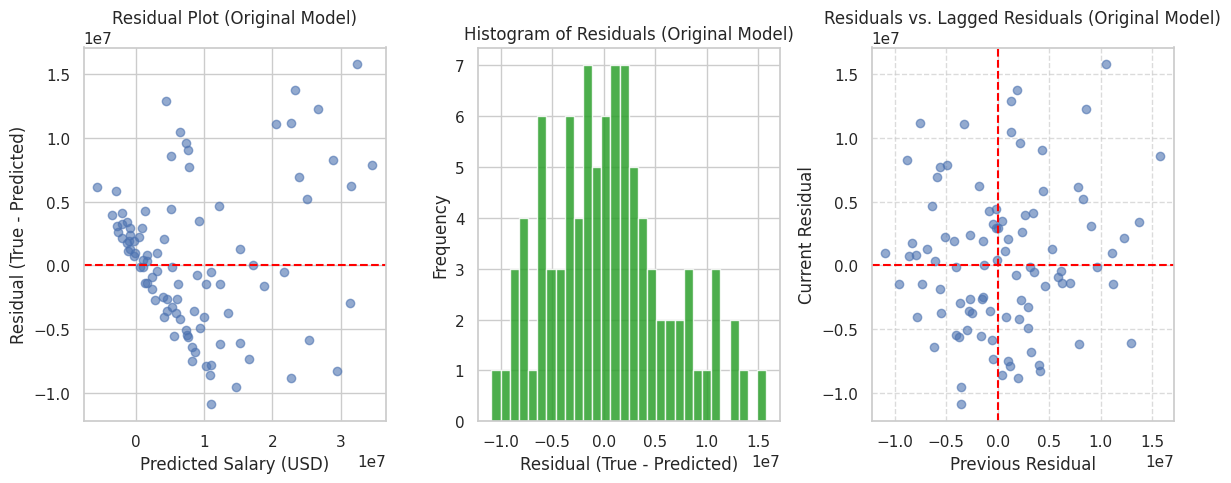

In [120]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Residual Plot (left subplot)
axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Salary (USD)')
axes[0].set_ylabel('Residual (True - Predicted)')
axes[0].set_title('Residual Plot (Original Model)')

# Histogram of Residuals (right subplot)
axes[1].hist(residuals, bins=30, color="#2ca02c", alpha=0.85)
axes[1].set_title('Histogram of Residuals (Original Model)')
axes[1].set_xlabel('Residual (True - Predicted)')
axes[1].set_ylabel('Frequency')

# Create a lagged version of the residuals
lagged_residuals = residuals.shift(1)

axes[2].scatter(lagged_residuals, residuals, alpha=0.6)
axes[2].set_title('Residuals vs. Lagged Residuals (Original Model)')
axes[2].set_xlabel('Previous Residual')
axes[2].set_ylabel('Current Residual')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Ploting the errors/residuals vs the fitted values allows us to see if the error of our predictions depends on the salary range. Despite residuals look normal and uncorrelated, we see a small funneling-out effect in the residuals, indicating a little bit of heteroskedasticity.

# 6 Exploring Non-Linear Terms: Log Transformation of Target

One common approach to handle right-skewed target variables and introduce non-linearity into the model's relationship with the predictors is to apply a logarithmic transformation. This can help stabilize the variance of the residuals and make the error distribution more Gaussian, which are often assumptions of linear regression models.

We will transform the `y_train` and `y_test` (Salary) by taking their natural logarithm. Remember that after prediction, you would need to exponentiate the predictions back to the original scale to interpret them in USD.

In [122]:
y_train_log = np.log1p(y_train) # log1p handles zero values by computing log(1+x)
y_test_log = np.log1p(y_test)

print(f"Original y_train mean: {y_train.mean():,.2f}")
print(f"Transformed y_train_log mean: {y_train_log.mean():.2f}")

print(f"Original y_test mean: {y_test.mean():,.2f}")
print(f"Transformed y_test_log mean: {y_test_log.mean():.2f}")

Original y_train mean: 8,261,276.57
Transformed y_train_log mean: 15.10
Original y_test mean: 9,032,930.35
Transformed y_test_log mean: 14.97


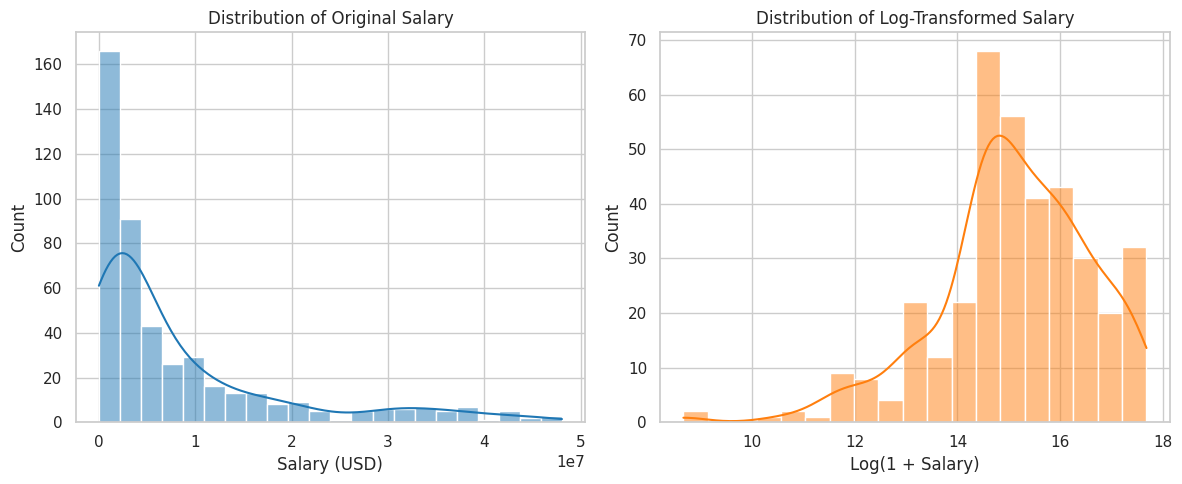

In [123]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Salary'], kde=True, color='#1f77b4')
plt.title('Distribution of Original Salary')
plt.xlabel('Salary (USD)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(y_train_log, kde=True, color='#ff7f0e')
plt.title('Distribution of Log-Transformed Salary')
plt.xlabel('Log(1 + Salary)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

We rerun the model with the log transformed salary

In [124]:
final_model_log = LinearRegression()
final_model_log.fit(X_train_selected, y_train_log)

y_pred_log = final_model_log.predict(X_test_selected)
y_pred_original_scale = np.expm1(y_pred_log) # Exponentiate back to original scale

r2_log = metrics.r2_score(y_test, y_pred_original_scale)
mae_log = metrics.mean_absolute_error(y_test, y_pred_original_scale)
mse_log = metrics.mean_squared_error(y_test, y_pred_original_scale)
rmse_log = np.sqrt(mse_log)

print(f"Model with Log-Transformed Target:")
print(f"Test R^2: {r2_log:.3f} Test MAE: {mae_log:,.0f} Test RMSE: {rmse_log:,.0f}")

Model with Log-Transformed Target:
Test R^2: 0.560 Test MAE: 4,829,838 Test RMSE: 7,643,811


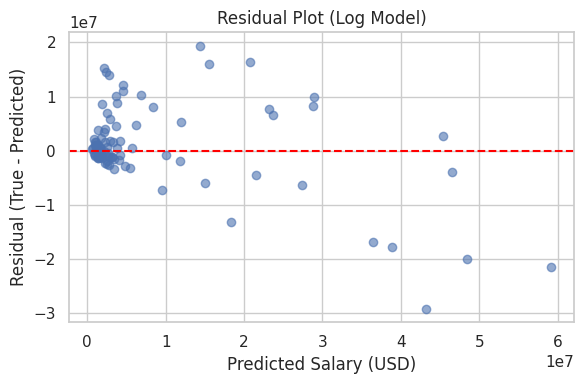

In [125]:
#  Visualize results with log-transformed target model
plot_df_log = pd.DataFrame({'True Salary': y_test, 'Predicted Salary': y_pred_original_scale})
fig_log = px.scatter(
    plot_df_log,
    x='True Salary', y='Predicted Salary',
    title='True vs. Predicted Salary (Test Set, Log Model)',
    hover_data=['True Salary', 'Predicted Salary'],
    labels={'True Salary': 'True Salary (USD)', 'Predicted Salary': 'Predicted Salary (USD)'}
)
fig_log.add_shape(
    type='line', line=dict(dash='dash', color='red'),
    x0=plot_df_log['True Salary'].min(), y0=plot_df_log['True Salary'].min(),
    x1=plot_df_log['True Salary'].max(), y1=plot_df_log['True Salary'].max()
)
fig_log.show()

residuals_log = y_test - y_pred_original_scale
fig_res_log, ax_res_log = plt.subplots(figsize=(6,4))
ax_res_log.scatter(y_pred_original_scale, residuals_log, alpha=0.6)
ax_res_log.axhline(0, color='red', linestyle='--')
ax_res_log.set_xlabel('Predicted Salary (USD)')
ax_res_log.set_ylabel('Residual (True - Predicted)')
ax_res_log.set_title('Residual Plot (Log Model)')
plt.tight_layout()
plt.show()

This transformation made this worse, despite solving the heteroskedasticity. Even though the original model is not terrible, we should test more advanced models. We will see those in ML II.

## Variable Abbreviations Glossary

Here's a list of the abbreviations used for player statistics and their meanings, as typically found in NBA advanced metrics:

*   **GP**: Games Played
*   **GS**: Games Started
*   **MP**: Minutes Played per Game
*   **FG**: Field Goals Made per Game
*   **FGA**: Field Goal Attempts per Game
*   **FG%**: Field Goal Percentage
*   **3P**: 3-Point Field Goals Made per Game
*   **3PA**: 3-Point Field Goal Attempts per Game
*   **3P%**: 3-Point Field Goal Percentage
*   **2P**: 2-Point Field Goals Made per Game
*   **2PA**: 2-Point Field Goal Attempts per Game
*   **2P%**: 2-Point Field Goal Percentage
*   **eFG%**: Effective Field Goal Percentage (adjusts for 3-pointers being worth more than 2-pointers)
*   **FT**: Free Throws Made per Game
*   **FTA**: Free Throw Attempts per Game
*   **FT%**: Free Throw Percentage
*   **ORB**: Offensive Rebounds per Game
*   **DRB**: Defensive Rebounds per Game
*   **TRB**: Total Rebounds per Game
*   **AST**: Assists per Game
*   **STL**: Steals per Game
*   **BLK**: Blocks per Game
*   **TOV**: Turnovers per Game
*   **PF**: Personal Fouls per Game
*   **PTS**: Points per Game
*   **PER**: Player Efficiency Rating
*   **TS%**: True Shooting Percentage (measures shooting efficiency while accounting for field goals, 3-pointers, and free throws)
*   **3PAr**: 3-Point Attempt Rate (percentage of field goal attempts that are 3-pointers)
*   **FTr**: Free Throw Attempt Rate (number of free throw attempts per field goal attempt)
*   **ORB%**: Offensive Rebound Percentage
*   **DRB%**: Defensive Rebound Percentage
*   **TRB%**: Total Rebound Percentage
*   **AST%**: Assist Percentage
*   **STL%**: Steal Percentage
*   **BLK%**: Block Percentage
*   **TOV%**: Turnover Percentage
*   **USG%**: Usage Percentage (estimates the percentage of team plays used by a player while they were on the floor)
*   **OWS**: Offensive Win Shares (estimates the player's offensive contributions to the team's wins)
*   **DWS**: Defensive Win Shares (estimates the player's defensive contributions to the team's wins)
*   **WS**: Win Shares (sum of OWS and DWS)
*   **WS/48**: Win Shares per 48 Minutes (measures player value per minute)
*   **OBPM**: Offensive Box Plus/Minus (estimates a player's offensive contribution per 100 possessions above league average)
*   **DBPM**: Defensive Box Plus/Minus (estimates a player's defensive contribution per 100 possessions above league average)
*   **BPM**: Box Plus/Minus (sum of OBPM and DBPM)
*   **VORP**: Value Over Replacement Player (estimates the total contribution of a player over a hypothetical "replacement player")